In [1]:
#Importing dependencies 

import numpy as np
import pandas as pd
import os
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array


2025-08-06 14:40:55.025862: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-06 14:40:55.174809: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754505655.241533 3711661 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754505655.261145 3711661 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754505655.366359 3711661 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
#Joining pandas dfs (train and test)

test_df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/PFED5/test_cnn.csv")
train_df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/PFED5/train_cnn.csv")

df = pd.concat([train_df, test_df], axis = 0)
df


,UPDRS_score,main_frame,description_clench the teeth,description_frown,description_sitting at rest,description_smile,description_squeeze eyes tightly
0,4,frames/001/12-104704_0/img_00032.jpg,0.0,0.0,1.0,0.0,0.0
1,2,frames/001/12-104704_1/img_00037.jpg,0.0,0.0,0.0,1.0,0.0
2,1,frames/001/12-104704_2/img_00038.jpg,0.0,1.0,0.0,0.0,0.0
3,1,frames/001/12-104704_3/img_00057.jpg,0.0,0.0,0.0,0.0,1.0
4,2,frames/001/12-104704_4/img_00046.jpg,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
759,2,frames/063/16-002607_0/img_00016.jpg,0.0,0.0,1.0,0.0,0.0
760,3,frames/063/16-002607_1/img_00063.jpg,0.0,0.0,0.0,1.0,0.0
761,4,frames/063/16-002607_2/img_00054.jpg,0.0,1.0,0.0,0.0,0.0
762,2,frames/063/16-002607_3/img_00048.jpg,0.0,0.0,0.0,0.0,1.0


In [3]:
#Scale numerical label
df["UPDRS_score"] = df["UPDRS_score"] / 4

In [4]:
#Balancing labels
labels = df['UPDRS_score'].values

from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))

In [5]:
#Load and preprocess image dataset

#Create a method pipeline for loading images
def load_data(df, base_dir, img_size=(224, 224)):
    #creating images and the corresponding labels
    images = []
    labels = []
    
    # iterating through each trow
    for _, row in df.iterrows():
        #graping the path of the image in my datafra,e
        img_path = os.path.join(base_dir, row["main_frame"])
        #scale the image 
        try:
            img = load_img(img_path, color_mode="grayscale", target_size=img_size)
            image = img_to_array(img) / 255.0
            images.append(image)

            # Multi-output labels ( 2 regression targets ), the UPDRS score and the description
            labels.append([    
                row["UPDRS_score"],
                row["description_clench the teeth"],
                row["description_frown"],
                row["description_sitting at rest"],
                row["description_smile"],
                row["description_squeeze eyes tightly"]

            ])
        except Exception as e:
            print("Error loading image:", img_path)
    
    #Return the labels and the features

    X = np.array(images)
    y = np.array(labels, dtype=np.float32)
    return X, y


In [6]:
#Splitting dataset 
from sklearn.model_selection import train_test_split

base_dir = "/users/imbahndu/Desktop/Columbia DBM/PFED5/" 

X, y = load_data (df, base_dir = base_dir)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [7]:
#Create convulation layers and using data augmentation for images

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.1, 0.1),
    keras.layers.RandomContrast(0.1)])

#Building up the layers

cnn_model = keras.Sequential()

#Building 1st layer
input_layer = keras.layers.InputLayer(input_shape = (224, 224, 1))
cnn_model.add(input_layer)
cnn_model.add(data_augmentation)

#Building 2nd layer
hidden_layer_1 = keras.layers.Conv2D(filters = 16, kernel_size =3 , padding = "same")
batchNorm_1 = keras.layers.BatchNormalization()
relu_1 = keras.layers.ReLU()
cnn_model.add(hidden_layer_1)
cnn_model.add(batchNorm_1)
cnn_model.add(relu_1)

#Pooling layer 
cnn_model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

#Building 3rd layer
hidden_layer_2 = keras.layers.Conv2D(filters = 32, kernel_size = 3, padding = "same")
batchNorm_2 = keras.layers.BatchNormalization()
relu_2 = keras.layers.ReLU()
cnn_model.add(hidden_layer_2)
cnn_model.add(batchNorm_2)
cnn_model.add(relu_2)

#Building 4th layer
hidden_layer_3 = keras.layers.Conv2D(filters = 64, kernel_size = 3, padding = "same")
batchNorm_3 = keras.layers.BatchNormalization()
relu_3 = keras.layers.ReLU()
cnn_model.add(hidden_layer_3)
cnn_model.add(batchNorm_3)
cnn_model.add(relu_3)

#Pooling layer
cnn_model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

#Building 5th layer
hidden_layer_4 = keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = "same")
batchNorm_4 = keras.layers.BatchNormalization()
relu_4 = keras.layers.ReLU()
cnn_model.add(hidden_layer_4)
cnn_model.add(batchNorm_4)
cnn_model.add(relu_4)

#Adding pooling layer for translation invariance
pooling_layer = keras.layers.GlobalAveragePooling2D()
cnn_model.add(pooling_layer)

#Regularization
cnn_model.add(keras.layers.Dropout(0.5))

#Adding output layer
output_layer = keras.layers.Dense(6, activation="linear")
cnn_model.add(output_layer)


#Summary 
cnn_model.summary()

2025-08-06 14:41:37.398792: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/users/imbahndu/.local/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,886 (386.27 KB)

 Trainable params: 98,406 (384.40 KB)

 Non-trainable params: 480 (1.88 KB)

In [8]:
#compiling the model with loss_fn and optimizer

cnn_model.compile(optimizer = "adam", loss = "mae", metrics = ["mse"])

In [9]:
#fitting the model
num_epochs = 10
history = cnn_model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 444s 9s/step - loss: 0.5145 - mse: 0.4807 - val_loss: 0.2708 - val_mse: 0.1781
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 357s 7s/step - loss: 0.3009 - mse: 0.1906 - val_loss: 0.2555 - val_mse: 0.1800
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 312s 6s/step - loss: 0.2635 - mse: 0.1819 - val_loss: 0.2333 - val_mse: 0.1761
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 382s 7s/step - loss: 0.2484 - mse: 0.1768 - val_loss: 0.2287 - val_mse: 0.1827
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 507s 9s/step - loss: 0.2345 - mse: 0.1772 - val_loss: 0.2167 - val_mse: 0.1817
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 602s 11s/step - loss: 0.2219 - mse: 0.1773 - val_loss: 0.2137 - val_mse: 0.1823
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 597s 11s/step - loss: 0.2158 - mse: 0.1791 - val_loss: 0.2139 - val_mse: 0.1825
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 703s 14s/step - loss: 0.2122 - mse: 0.1801 - val_loss: 0.2118 - val_mse: 0.1819
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 543s 11s/step - loss: 0

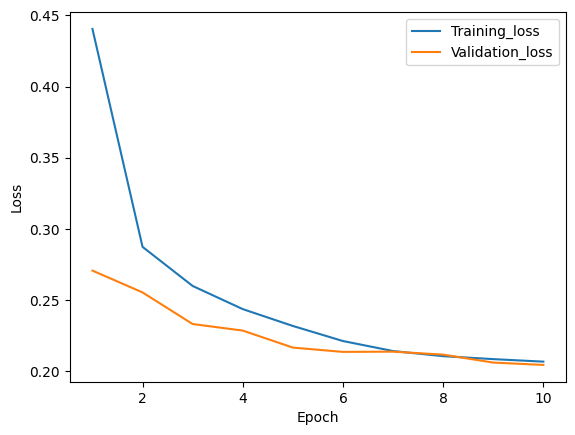

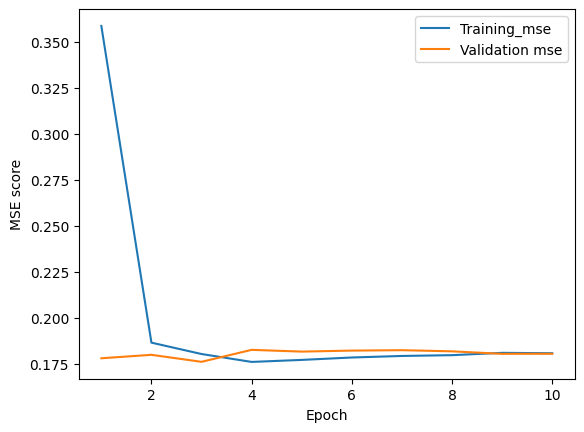

In [10]:
#plotting to see if everything is consistent 
import matplotlib.pyplot as plt
import seaborn as sns

#Plot training and validation loss
num_epochs = 10
plt.plot(range(1, num_epochs+1 ), history.history['loss'], label = "Training_loss")
plt.plot (range(1, num_epochs + 1), history.history["val_loss"], label = "Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Plotting training and validation mse
plt.plot(range(1, num_epochs+1), history.history["mse"], label = "Training_mse")
plt.plot(range(1, num_epochs +1 ), history.history["val_mse"], label = "Validation mse")
plt.xlabel("Epoch")
plt.ylabel("MSE score")
plt.legend()
plt.show()

In [11]:
#Evaluation on test set
loss, mse = cnn_model.evaluate(X_test, y_test)

print("Loss is ", loss)
print("MSE is ", mse)

27/27 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - loss: 0.2059 - mse: 0.1816
Loss is  0.2069300413131714
MSE is  0.1823400855064392


In [12]:
from sklearn.metrics import classification_report 

prob_predict = cnn_model.predict(X_test)

y_pred = (prob_predict > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names = target_names))


27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step


NameError: name 'target_names' is not defined

In [ ]:
#Making predictions on the test dataset and doing classification report 

prob_predict = cnn_model.predict(X_test[:844])

from sklearn.metrics import classification_report

#predictions
y_pred = (prob_predict > 0.5).astype(int)

#gettting the categorical values
target_names = []
for col in df.columns:
    if col.startswith("description"):
        target_names.append(col)

target_names

#obtaining true values for cat columns
y_true = df[target_names]

27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 676ms/step


In [ ]:
print(classification_report(y_test, y_pred, target_names = target_names))

ValueError: Classification metrics can't handle a mix of continuous-multioutput and multilabel-indicator targets

In [ ]:
#mea score for evaluation 

from sklearn.metrics import mean_squared_error

y_updrs = cnn_model.predict(X_test)

mea = mean_squared_error(df["UPDRS_score"], y_updrs)

27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step


ValueError: Found input variables with inconsistent numbers of samples: [2811, 844]